# Eje 1c — Opciones: Payoffs, PnL y Casos de Estudio

Derivados Financieros — QUANt UCEMA  
Clase 1 (slides 34–53)

Plan del notebook:

1. Posiciones Long/Short
2. Payoffs de las 4 posiciones básicas
3. PnL (Payoff − Prima)
4. Valor intrínseco y moneyness
5. Venta cubierta vs descubierta, margen
6. Casos de estudio: Especulación, Cobertura, Straddle

In [1]:
import sys
sys.path.append('../../..')

import numpy as np
import matplotlib.pyplot as plt

from Codigo.analytics.payoffs import payoff_call, payoff_put, payoff_protective_put, payoff_straddle

## 1) Posiciones Long y Short

Para cada contrato de opciones hay dos patas:

- **Long**: compro la opción (pago prima, tengo el derecho)
- **Short**: vendo o escribo la opción (recibo prima, asumo la obligación)

El escritor recibe dinero up-front pero tiene potenciales riesgos. El escritor de un call podría estar long el subyacente y necesitaría cubrir ante una bajada. El escritor de una put podría estar short el subyacente y necesitaría cubrir ante una subida.

## 2) Payoffs — 4 posiciones básicas

- **Long call**: $\max(S_T - K, 0)$
- **Long put**: $\max(K - S_T, 0)$
- **Short call**: $-\max(S_T - K, 0)$
- **Short put**: $-\max(K - S_T, 0)$

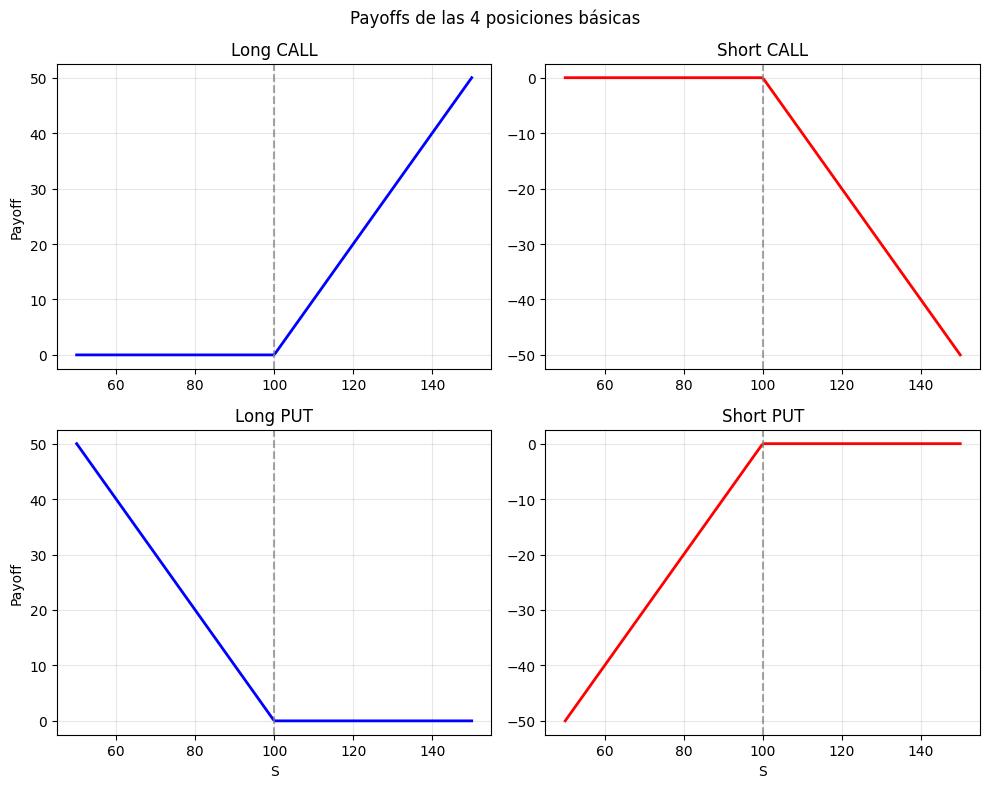

In [2]:
K = 100
S = np.linspace(50, 150, 200)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].plot(S, payoff_call(S, K), 'b-', lw=2)
axes[0,0].axvline(K, color='gray', ls='--', alpha=0.7)
axes[0,0].set_title('Long CALL')
axes[0,0].set_ylabel('Payoff')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(S, -payoff_call(S, K), 'r-', lw=2)
axes[0,1].axvline(K, color='gray', ls='--', alpha=0.7)
axes[0,1].set_title('Short CALL')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(S, payoff_put(S, K), 'b-', lw=2)
axes[1,0].axvline(K, color='gray', ls='--', alpha=0.7)
axes[1,0].set_title('Long PUT')
axes[1,0].set_xlabel('S')
axes[1,0].set_ylabel('Payoff')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(S, -payoff_put(S, K), 'r-', lw=2)
axes[1,1].axvline(K, color='gray', ls='--', alpha=0.7)
axes[1,1].set_title('Short PUT')
axes[1,1].set_xlabel('S')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Payoffs de las 4 posiciones básicas', fontsize=12)
plt.tight_layout()
plt.show()

## 3) PnL = Payoff − Prima

La **ganancia** (PnL) incluye la prima pagada/recibida:

$$\text{PnL} = \text{Payoff} - \text{Prima pagada} \quad \text{(o } + \text{ si prima recibida)}$$

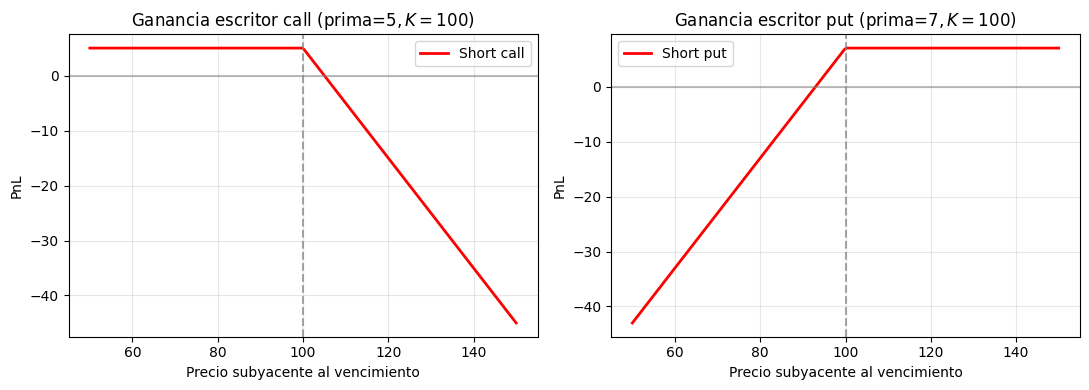

In [3]:
K = 100
prima_call, prima_put = 5, 7
S = np.linspace(50, 150, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# PnL escritor call (recibe prima, paga payoff)
ax1.plot(S, prima_call - payoff_call(S, K), 'r-', lw=2, label='Short call')
ax1.axvline(K, color='gray', ls='--', alpha=0.7)
ax1.axhline(0, color='gray', ls='-', alpha=0.5)
ax1.set_xlabel('Precio subyacente al vencimiento')
ax1.set_ylabel('PnL')
ax1.set_title(f'Ganancia escritor call (prima=${prima_call}, K=${K})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PnL escritor put
ax2.plot(S, prima_put - payoff_put(S, K), 'r-', lw=2, label='Short put')
ax2.axvline(K, color='gray', ls='--', alpha=0.7)
ax2.axhline(0, color='gray', ls='-', alpha=0.5)
ax2.set_xlabel('Precio subyacente al vencimiento')
ax2.set_ylabel('PnL')
ax2.set_title(f'Ganancia escritor put (prima=${prima_put}, K=${K})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4) Valor intrínseco y Moneyness

**Valor intrínseco (VI):** Diferencia entre precio del subyacente y strike. Siempre ≥ 0.

- Call: VI = max(S − K, 0)
- Put: VI = max(K − S, 0)

Al vencimiento, VI = Payoff. **Valor temporal** = Precio − VI.

**Moneyness:**

- **ITM** (in the money): opción con valor intrínseco positivo
- **ATM** (at the money): S ≈ K
- **OTM** (out of the money): sin valor intrínseco

## 5) Venta cubierta vs descubierta (naked)

- **Venta cubierta**: típica cobertura (ej. long subyacente + short call)
- **Venta descubierta (naked)**: riesgo mucho mayor; muchos brokers no la permiten a nivel minorista
- Lotes: contratos suelen ser por 100 unidades del subyacente

**Margen (CBOE):** La prima de una opción NO puede pagarse con margen. La venta descubierta implica margen. Ejemplo: call $5, K=$40, S=$38 → margen = max(1060, 880) por contrato.

## 6) Caso 1 — Especulación (AAPL)

Acción AAPL a $200. Creemos que subirá en 3 meses.

**Inversión 1:** Comprar acción. Riesgo: sin piso (puedo perder todo). Beneficio: sin techo.

**Inversión 2:** Comprar call K=$210, prima $12. Menor exposición a la baja:
- S < 210: no ejerzo, pierdo $12 (piso)
- S entre 210–222: ejerzo, reduzco pérdida hasta 0
- S > 222: ejerzo, ganancia (break-even = $222)

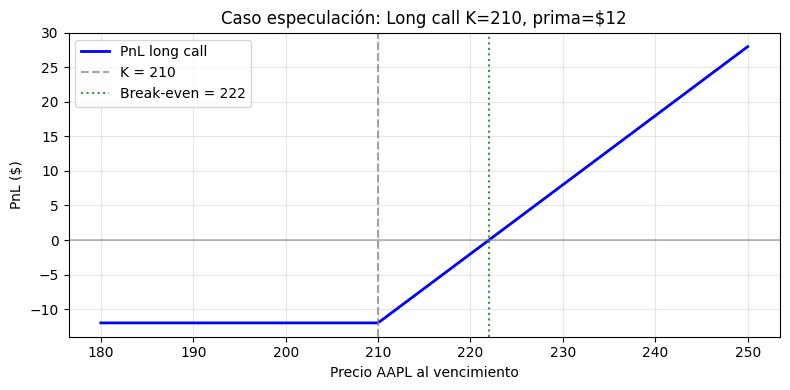

In [4]:
# Caso AAPL: call K=210, prima=12
K_aapl, prima = 210, 12
S_aapl = np.linspace(180, 250, 200)
pnl_call = payoff_call(S_aapl, K_aapl) - prima

plt.figure(figsize=(8, 4))
plt.plot(S_aapl, pnl_call, 'b-', lw=2, label='PnL long call')
plt.axvline(K_aapl, color='gray', ls='--', alpha=0.7, label=f'K = {K_aapl}')
plt.axvline(K_aapl + prima, color='green', ls=':', alpha=0.8, label=f'Break-even = {K_aapl + prima}')
plt.axhline(0, color='gray', ls='-', alpha=0.5)
plt.xlabel('Precio AAPL al vencimiento')
plt.ylabel('PnL ($)')
plt.title('Caso especulación: Long call K=210, prima=$12')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7) Caso 2 — Cobertura: Protective Put

Inversor compra acción a $150 y put con mismo strike. Protección ante caída, cediendo ganancia potencial.

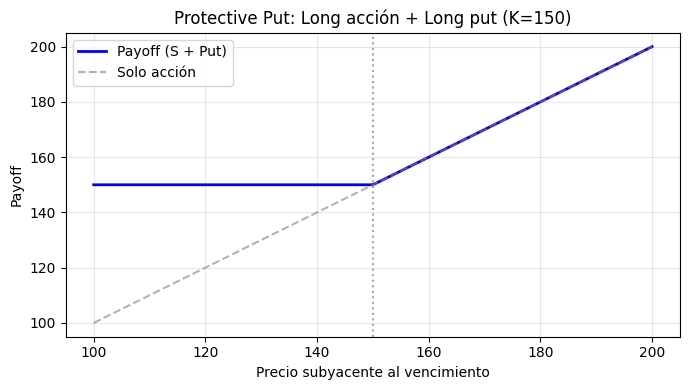

In [5]:
# Protective Put: S + Put(K). Payoff = max(S, K)
K_pp = 150
S_pp = np.linspace(100, 200, 200)
payoff_pp = payoff_protective_put(S_pp, K_pp)

plt.figure(figsize=(7, 4))
plt.plot(S_pp, payoff_pp, 'b-', lw=2, label='Payoff (S + Put)')
plt.plot(S_pp, S_pp, 'gray', ls='--', alpha=0.6, label='Solo acción')
plt.axvline(K_pp, color='gray', ls=':', alpha=0.7)
plt.xlabel('Precio subyacente al vencimiento')
plt.ylabel('Payoff')
plt.title('Protective Put: Long acción + Long put (K=150)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8) Caso 3 — Comprar volatilidad: Straddle

Call + Put mismo strike (ATM). Especula con movimiento importante sin dirección (earnings, elecciones, anuncios).

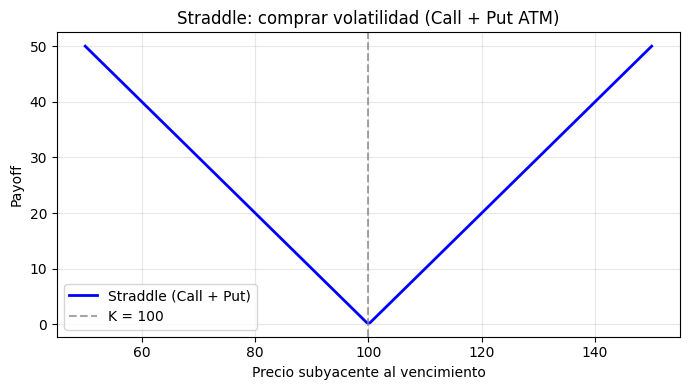

In [6]:
# Straddle: Call(K) + Put(K)
K_str = 100
S_str = np.linspace(50, 150, 200)
payoff_str = payoff_straddle(S_str, K_str)

plt.figure(figsize=(7, 4))
plt.plot(S_str, payoff_str, 'b-', lw=2, label='Straddle (Call + Put)')
plt.axvline(K_str, color='gray', ls='--', alpha=0.7, label=f'K = {K_str}')
plt.xlabel('Precio subyacente al vencimiento')
plt.ylabel('Payoff')
plt.title('Straddle: comprar volatilidad (Call + Put ATM)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Resumen

- 4 posiciones: Long/Short Call, Long/Short Put.
- PnL = Payoff − Prima (o + prima si short).
- VI, valor temporal, moneyness (ITM/ATM/OTM).
- Casos: especulación (call), cobertura (protective put), volatilidad (straddle).